In [17]:
import pandas as pd
import numpy as np
import random


# Dataset fixe
data = [
    ["PSG", "OM", "H"],
    ["Lyon", "Nice", "D"],
    ["Monaco", "Rennes", "A"],
    ["OM", "Lyon", "H"],
    ["PSG", "Monaco", "D"],
    ["Nice", "Rennes", "A"],
    ["Monaco", "OM", "H"],
    ["Rennes", "PSG", "A"],
    ["Lyon", "Monaco", "H"],
    ["Nice", "PSG", "D"],
    ["OM", "Rennes", "H"],
    ["Monaco", "Lyon", "A"],
    ["PSG", "Rennes", "H"],
    ["Nice", "OM", "D"],
    ["Rennes", "Lyon", "A"],
    ["Monaco", "PSG", "H"],
    ["Lyon", "Nice", "H"],
    ["OM", "PSG", "D"],
    ["Rennes", "Monaco", "H"],
    ["Nice", "Lyon", "A"]
]

df = pd.DataFrame(data, columns=["Team1", "Team2", "Result"])

# toutes les équipes uniques
teams = sorted(pd.unique(df[['Team1','Team2']].values.ravel()))
n = len(teams)
team_index = {team:i for i, team in enumerate(teams)}


In [18]:
teams

['Lyon', 'Monaco', 'Nice', 'OM', 'PSG', 'Rennes']

In [2]:
# Matrice des victoires : W[i,j] = nb de victoires de i contre j
W = np.zeros((n,n), dtype=int)

# Matrice des égalités : D[i,j] = nb de matchs nuls entre i et j
D = np.zeros((n,n), dtype=int)


In [3]:
for _, row in df.iterrows():
    i = team_index[row['Team1']]
    j = team_index[row['Team2']]
    
    if row['Result'] == 'H':
        W[i,j] += 1
    elif row['Result'] == 'A':
        W[j,i] += 1
    elif row['Result'] == 'D':
        D[i,j] += 1
        D[j,i] += 1  # symétrique


In [4]:
W_df = pd.DataFrame(W, index=teams, columns=teams)
D_df = pd.DataFrame(D, index=teams, columns=teams)

print("Matrice des victoires :\n", W_df)
print("\nMatrice des égalités :\n", D_df)


Matrice des victoires :
         Lyon  Monaco  Nice  OM  PSG  Rennes
Lyon       0       2     2   0    0       1
Monaco     0       0     0   1    1       0
Nice       0       0     0   0    0       0
OM         1       0     0   0    0       1
PSG        0       0     0   1    0       2
Rennes     0       2     1   0    0       0

Matrice des égalités :
         Lyon  Monaco  Nice  OM  PSG  Rennes
Lyon       0       0     1   0    0       0
Monaco     0       0     0   0    1       0
Nice       1       0     0   1    1       0
OM         0       0     1   0    1       0
PSG        0       1     1   1    0       0
Rennes     0       0     0   0    0       0


In [5]:
from BradleyTerry_classical.BT_classical import BradleyTerry

In [6]:
a = BradleyTerry()
a.fit(W)


Algorithm terminates after 1000 iterations


In [7]:
theta = a.predict()
theta


array([-4.05458469,  2.47388782,  2.37070731,  0.21136701, -1.98437721,
        0.98299976])

In [8]:
forces = pd.DataFrame({
    "Team": teams,
    "Strength": theta
}).sort_values(by="Strength", ascending=False)

print("Forces estimées de chaque équipe :\n")
forces

Forces estimées de chaque équipe :



,Team,Strength
1,Monaco,2.473888
2,Nice,2.370707
5,Rennes,0.983000
3,OM,0.211367
4,PSG,-1.984377
0,Lyon,-4.054585


In [12]:
df

,Team1,Team2,Result
0,PSG,OM,H
1,Lyon,Nice,D
2,Monaco,Rennes,A
3,OM,Lyon,H
4,PSG,Monaco,D
5,Nice,Rennes,A
6,Monaco,OM,H
7,Rennes,PSG,A
8,Lyon,Monaco,H
9,Nice,PSG,D


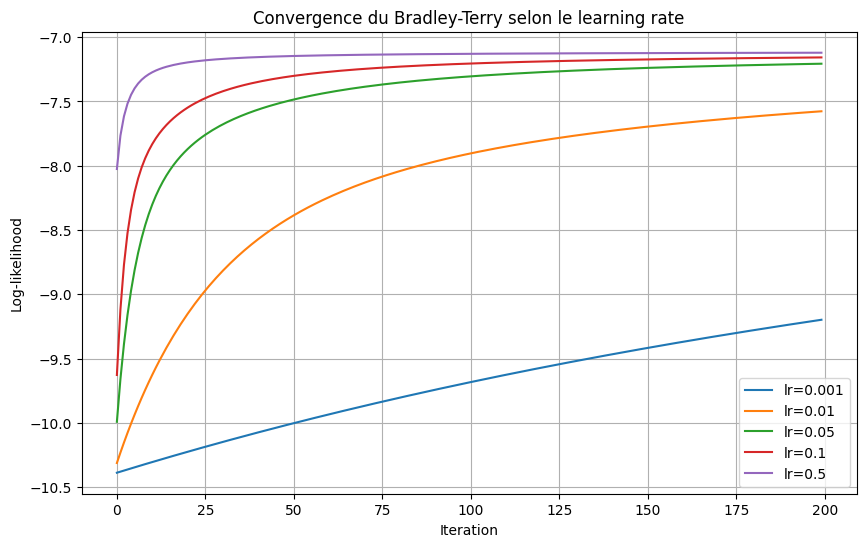

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# J'assume que ta classe BradleyTerry est déjà définie
# et que W est ta matrice des victoires

learning_rates = [0.001, 0.01, 0.05, 0.1, 0.5]
n_iterations = 200  # juste pour visualiser la tendance

plt.figure(figsize=(10,6))

for lr in learning_rates:
    bt = BradleyTerry(learning_rate=lr, n_iterations=n_iterations, tolerance=1e-8)
    bt.theta = np.zeros(W.shape[0])
    bt.X = W  # stocker W dans l'objet pour log_gradient/loglikelihood

    ll_values = []
    theta = bt.theta.copy()
    
    for _ in range(n_iterations):
        grad = bt.log_gradient(theta)
        theta += lr * grad  # mise à jour
        theta -= np.mean(theta)  # centrage pour identification
        ll_values.append(bt.loglikelihood(theta))

    plt.plot(ll_values, label=f"lr={lr}")

plt.xlabel("Iteration")
plt.ylabel("Log-likelihood")
plt.title("Convergence du Bradley-Terry selon le learning rate")
plt.legend()
plt.grid(True)
plt.show()


In [11]:
from Data.data_processing import DataProcesser

Processer = DataProcesser("./Data/Dataset_clean.csv")

matrix = Processer.filter_year("10-11").get_result_matrix()

matrix

array([[0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0],
       [2, 0, 0, 0, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1],
       [2, 2, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 2, 1, 0, 1, 0, 1],
       [1, 2, 1, 0, 1, 1, 0, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 0, 1],
       [1, 1, 2, 1, 0, 1, 0, 1, 1, 2, 1, 1, 0, 2, 0, 1, 0, 1, 1, 1],
       [1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 2, 0, 1, 0, 1, 0, 1, 0, 1],
       [2, 1, 1, 2, 2, 2, 0, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 2, 1, 1],
       [1, 0, 1, 1, 1, 2, 1, 0, 1, 1, 1, 1, 1, 0, 1, 2, 1, 2, 1, 1],
       [1, 1, 1, 1, 1, 2, 1, 1, 0, 1, 2, 2, 2, 1, 1, 1, 2, 1, 1, 1],
       [2, 1, 1, 1, 0, 2, 1, 1, 1, 0, 1, 2, 2, 1, 1, 2, 2, 1, 2, 1],
       [2, 1, 2, 0, 1, 1, 1, 1, 0, 1, 0, 2, 1, 1, 1, 1, 1, 0, 1, 0],
       [1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 2, 1, 1, 1, 0, 2, 2],
       [1, 1, 1, 0, 2, 2, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1],
       [1, 1, 1, 1, 0, 1, 0, 2, 1, 1, 1, 0, 1, 0, 0, 0, 1, 2, 1, 1],
       [2, 0, 0, 1, 2, 2, 1, 1, 1,